In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research"
ZIP_PATH = f"{PROJECT_DIR}/dataset/citipersons.zip"

os.makedirs(WORK_DIR, exist_ok=True)
shutil.copy(ZIP_PATH, f"{WORK_DIR}/citipersons.zip")
print("Copied zip to Colab VM")

Copied zip to Colab VM


In [4]:
import zipfile

with zipfile.ZipFile(f"{WORK_DIR}/citipersons.zip", 'r') as zip_ref:
    zip_ref.extractall(f"{WORK_DIR}/dataset")

print("Unzipped dataset")

Unzipped dataset


In [9]:
!ls /content/final-year-research/dataset/

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [18]:
import yaml

yaml_path = "/content/final-year-research/citypersons_colab.yaml"

data = {
    "path": "/content/final-year-research",
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {0: "ped"}
}

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print(open(yaml_path).read())

path: /content/final-year-research
train: train/images
val: valid/images
test: test/images
names:
  0: ped



In [11]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.7 MB/s eta 0:00:00


In [12]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU name: Tesla T4


In [19]:
import glob

ROOT = "/content/final-year-research"

print("train images:", len(glob.glob(ROOT + "/train/images/*")))
print("train labels:", len(glob.glob(ROOT + "/train/labels/*")))
print("valid images:", len(glob.glob(ROOT + "/valid/images/*")))
print("valid labels:", len(glob.glob(ROOT + "/valid/labels/*")))
print("test images:", len(glob.glob(ROOT + "/test/images/*")))
print("test labels:", len(glob.glob(ROOT + "/test/labels/*")))

train images: 5584
train labels: 5584
valid images: 342
valid labels: 342
test images: 341
test labels: 341


In [20]:
!yolo detect train model=yolov8n.pt data="/content/final-year-research/citypersons_colab.yaml" epochs=1 imgsz=640 batch=8 device=0

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final-year-research/citypersons_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0

In [21]:
!yolo detect train model=yolov8n.pt data="/content/final-year-research/citypersons_colab.yaml" epochs=50 imgsz=640 batch=16 device=0

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final-year-research/citypersons_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

In [22]:
import shutil, os

src = "/content/runs/detect/train2"
dst = "/content/drive/MyDrive/final-year-research/outputs/baseline_train2"

if os.path.exists(dst):
    shutil.rmtree(dst)

shutil.copytree(src, dst)
print("Baseline results saved to Drive:", dst)

Baseline results saved to Drive: /content/drive/MyDrive/final-year-research/outputs/baseline_train2


**Visualizing Baseline Model Results**

In [8]:
RUN_DIR = "/content/drive/MyDrive/final-year-research/outputs/baseline_train2"

Showing: BoxPR_curve.png


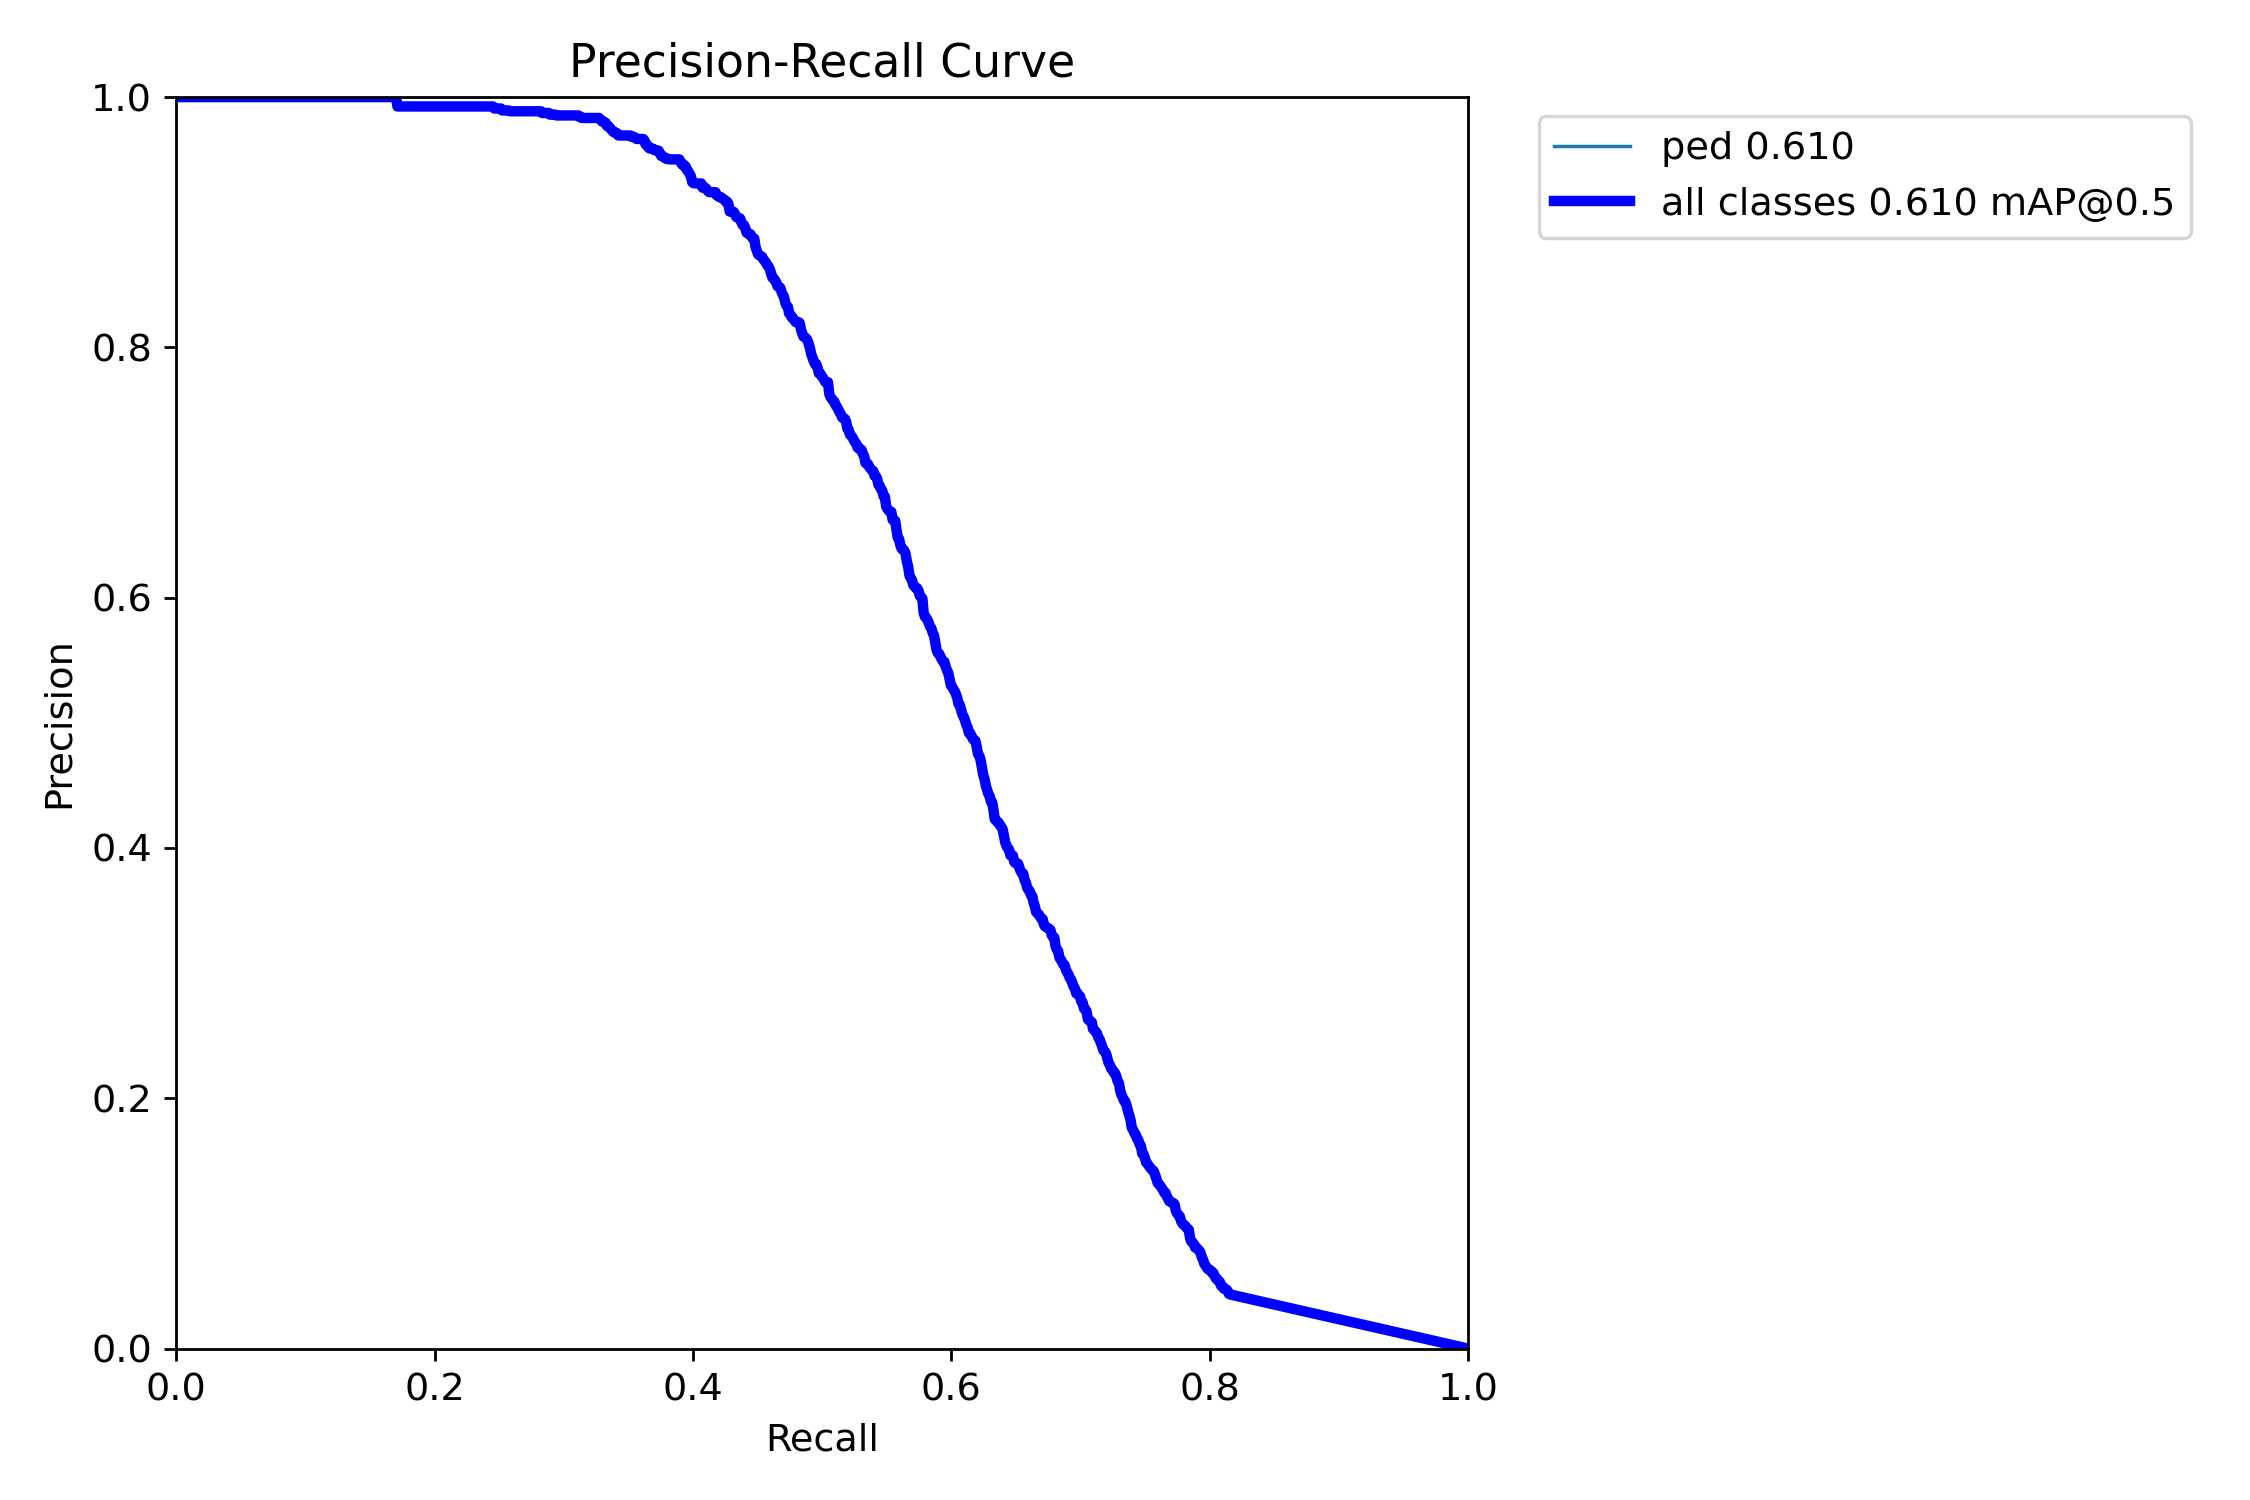

Showing: BoxF1_curve.png


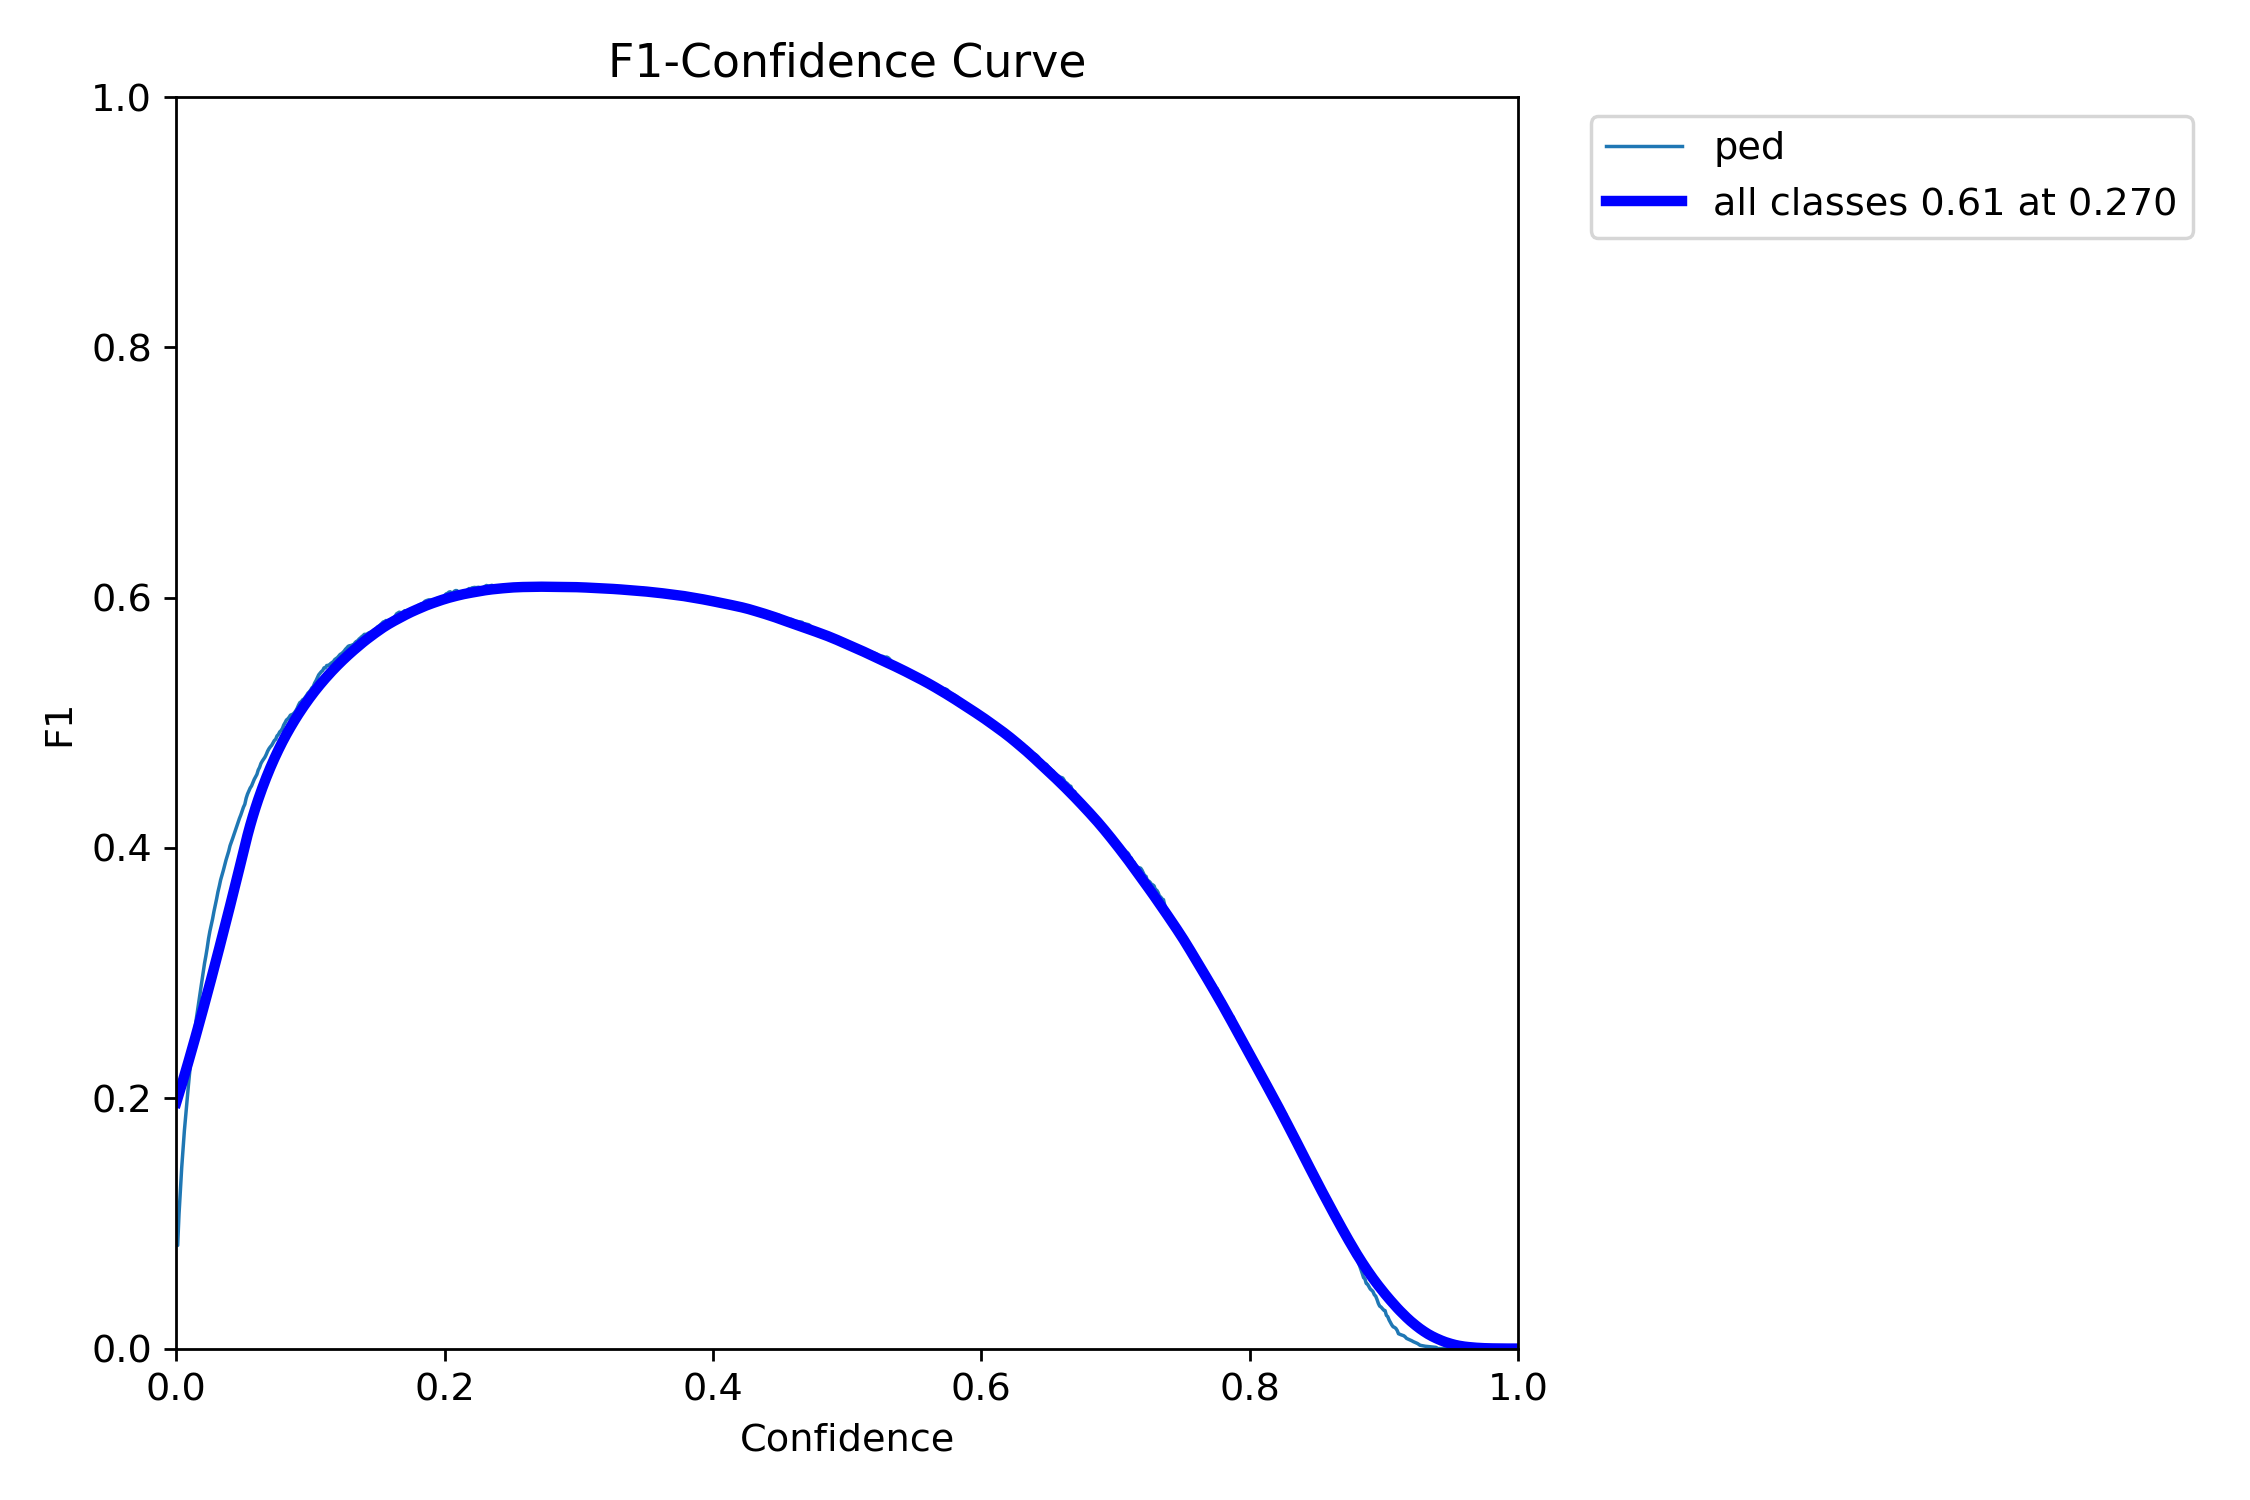

Showing: BoxR_curve.png


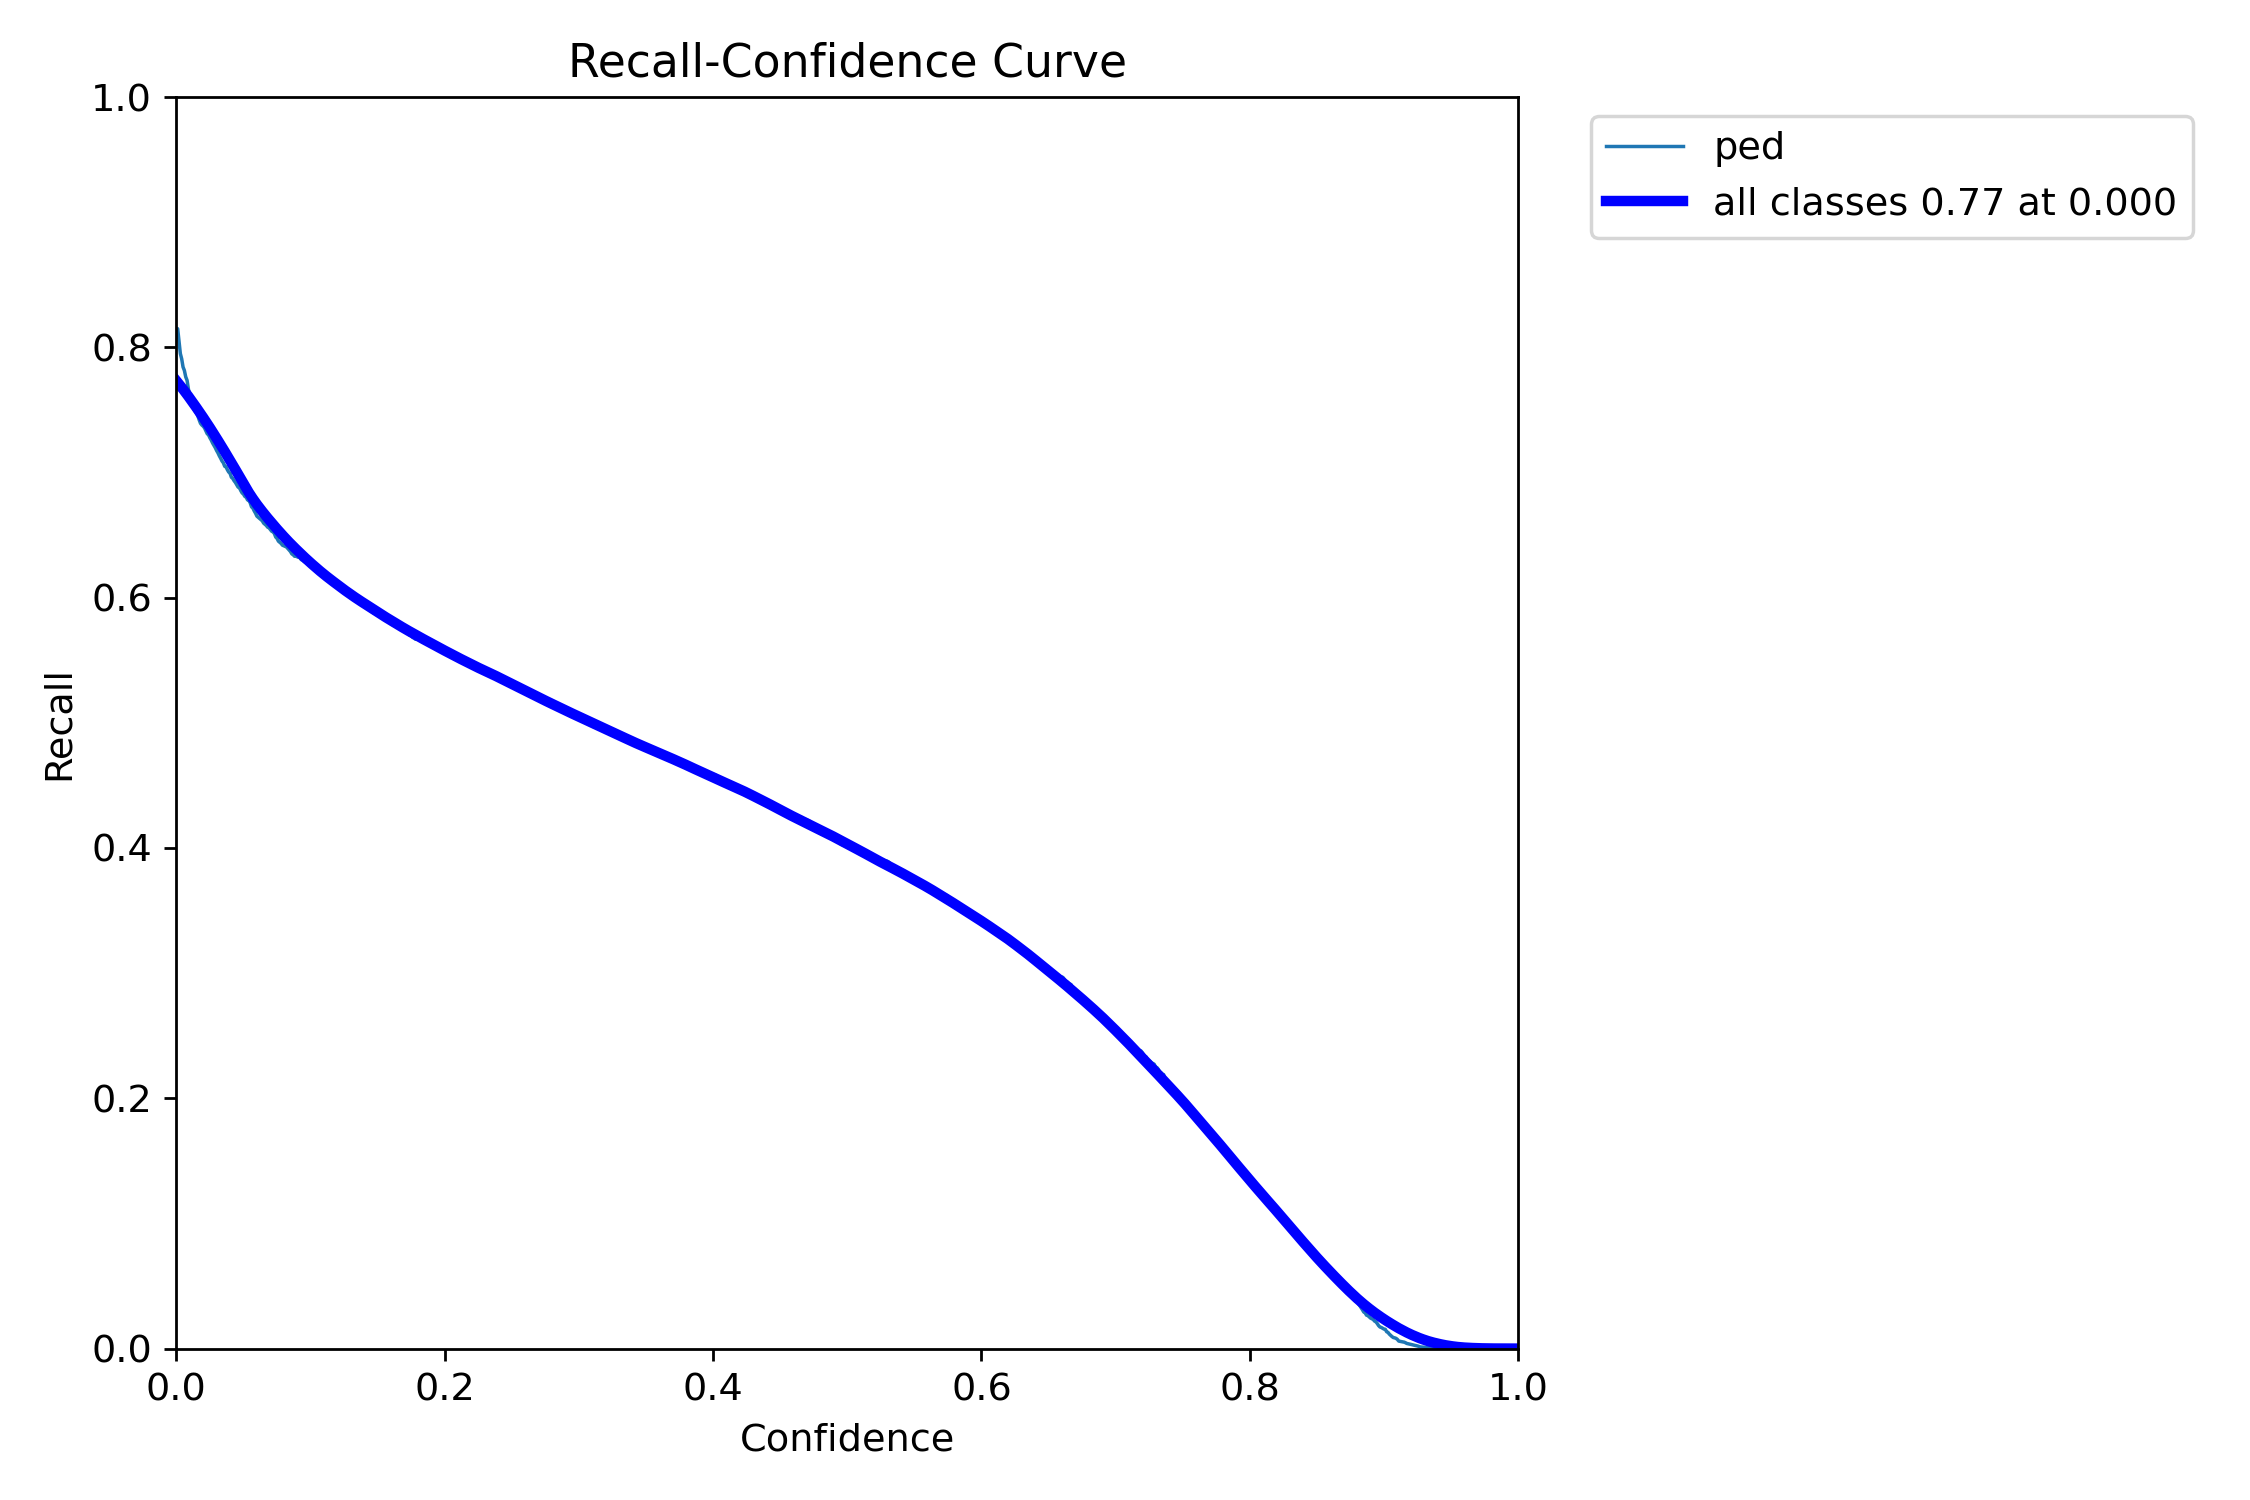

Showing: BoxP_curve.png


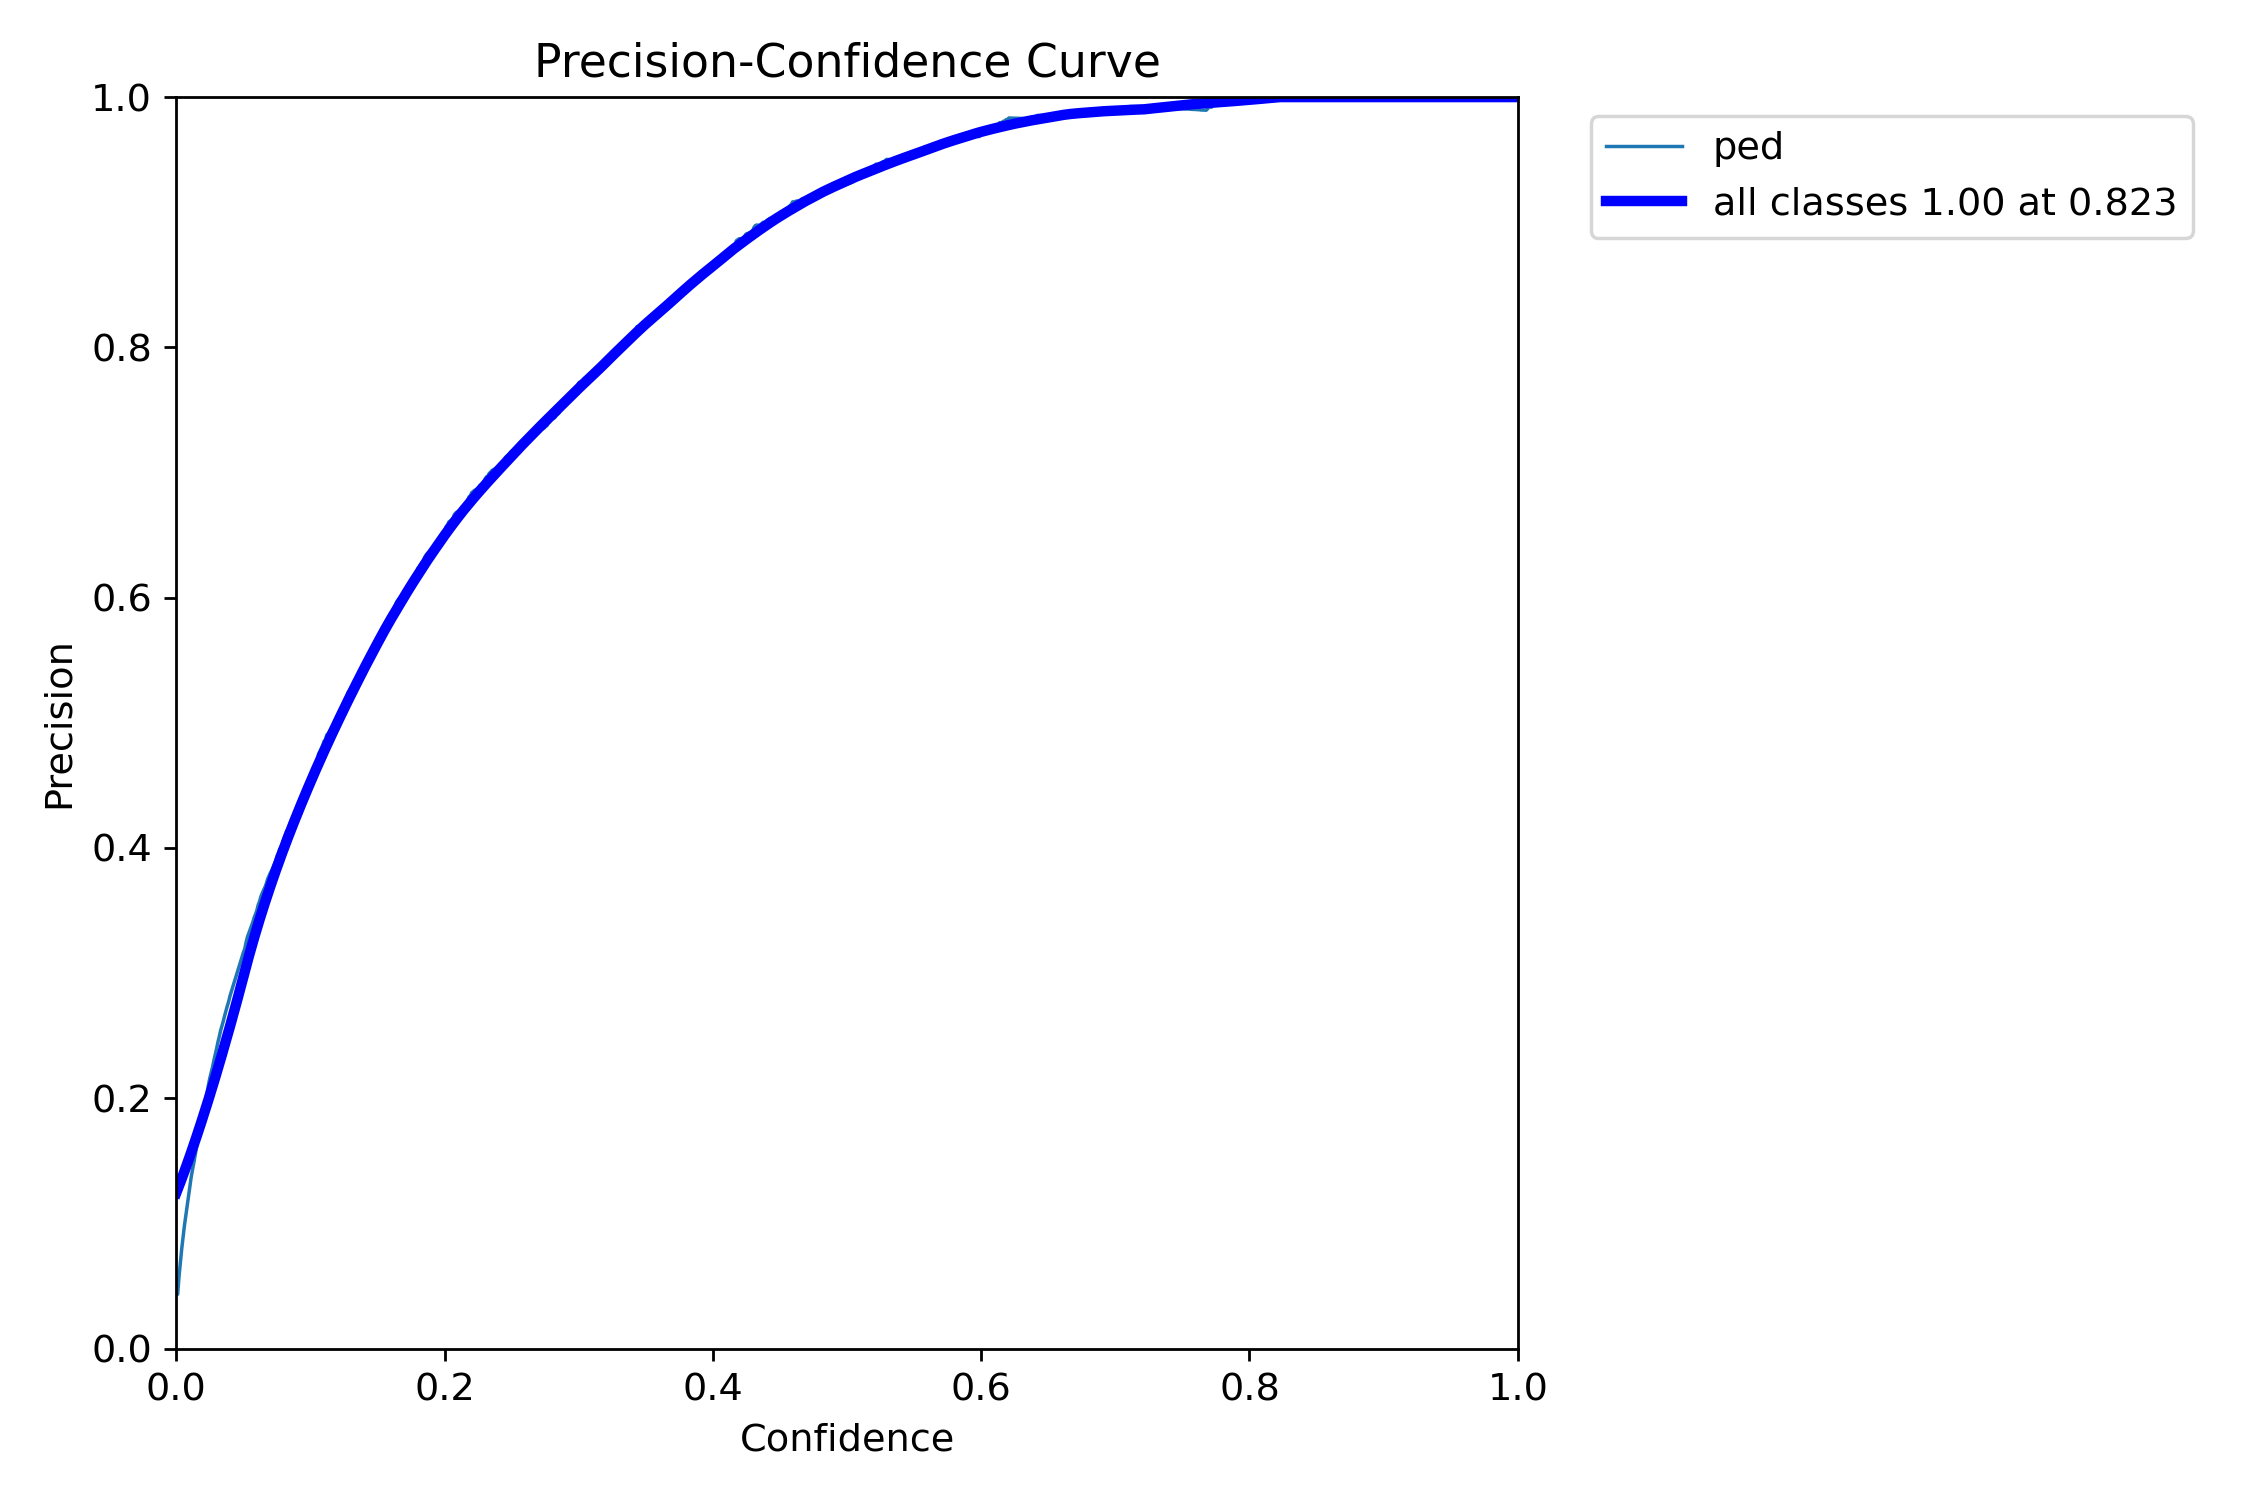

Showing: confusion_matrix_normalized.png


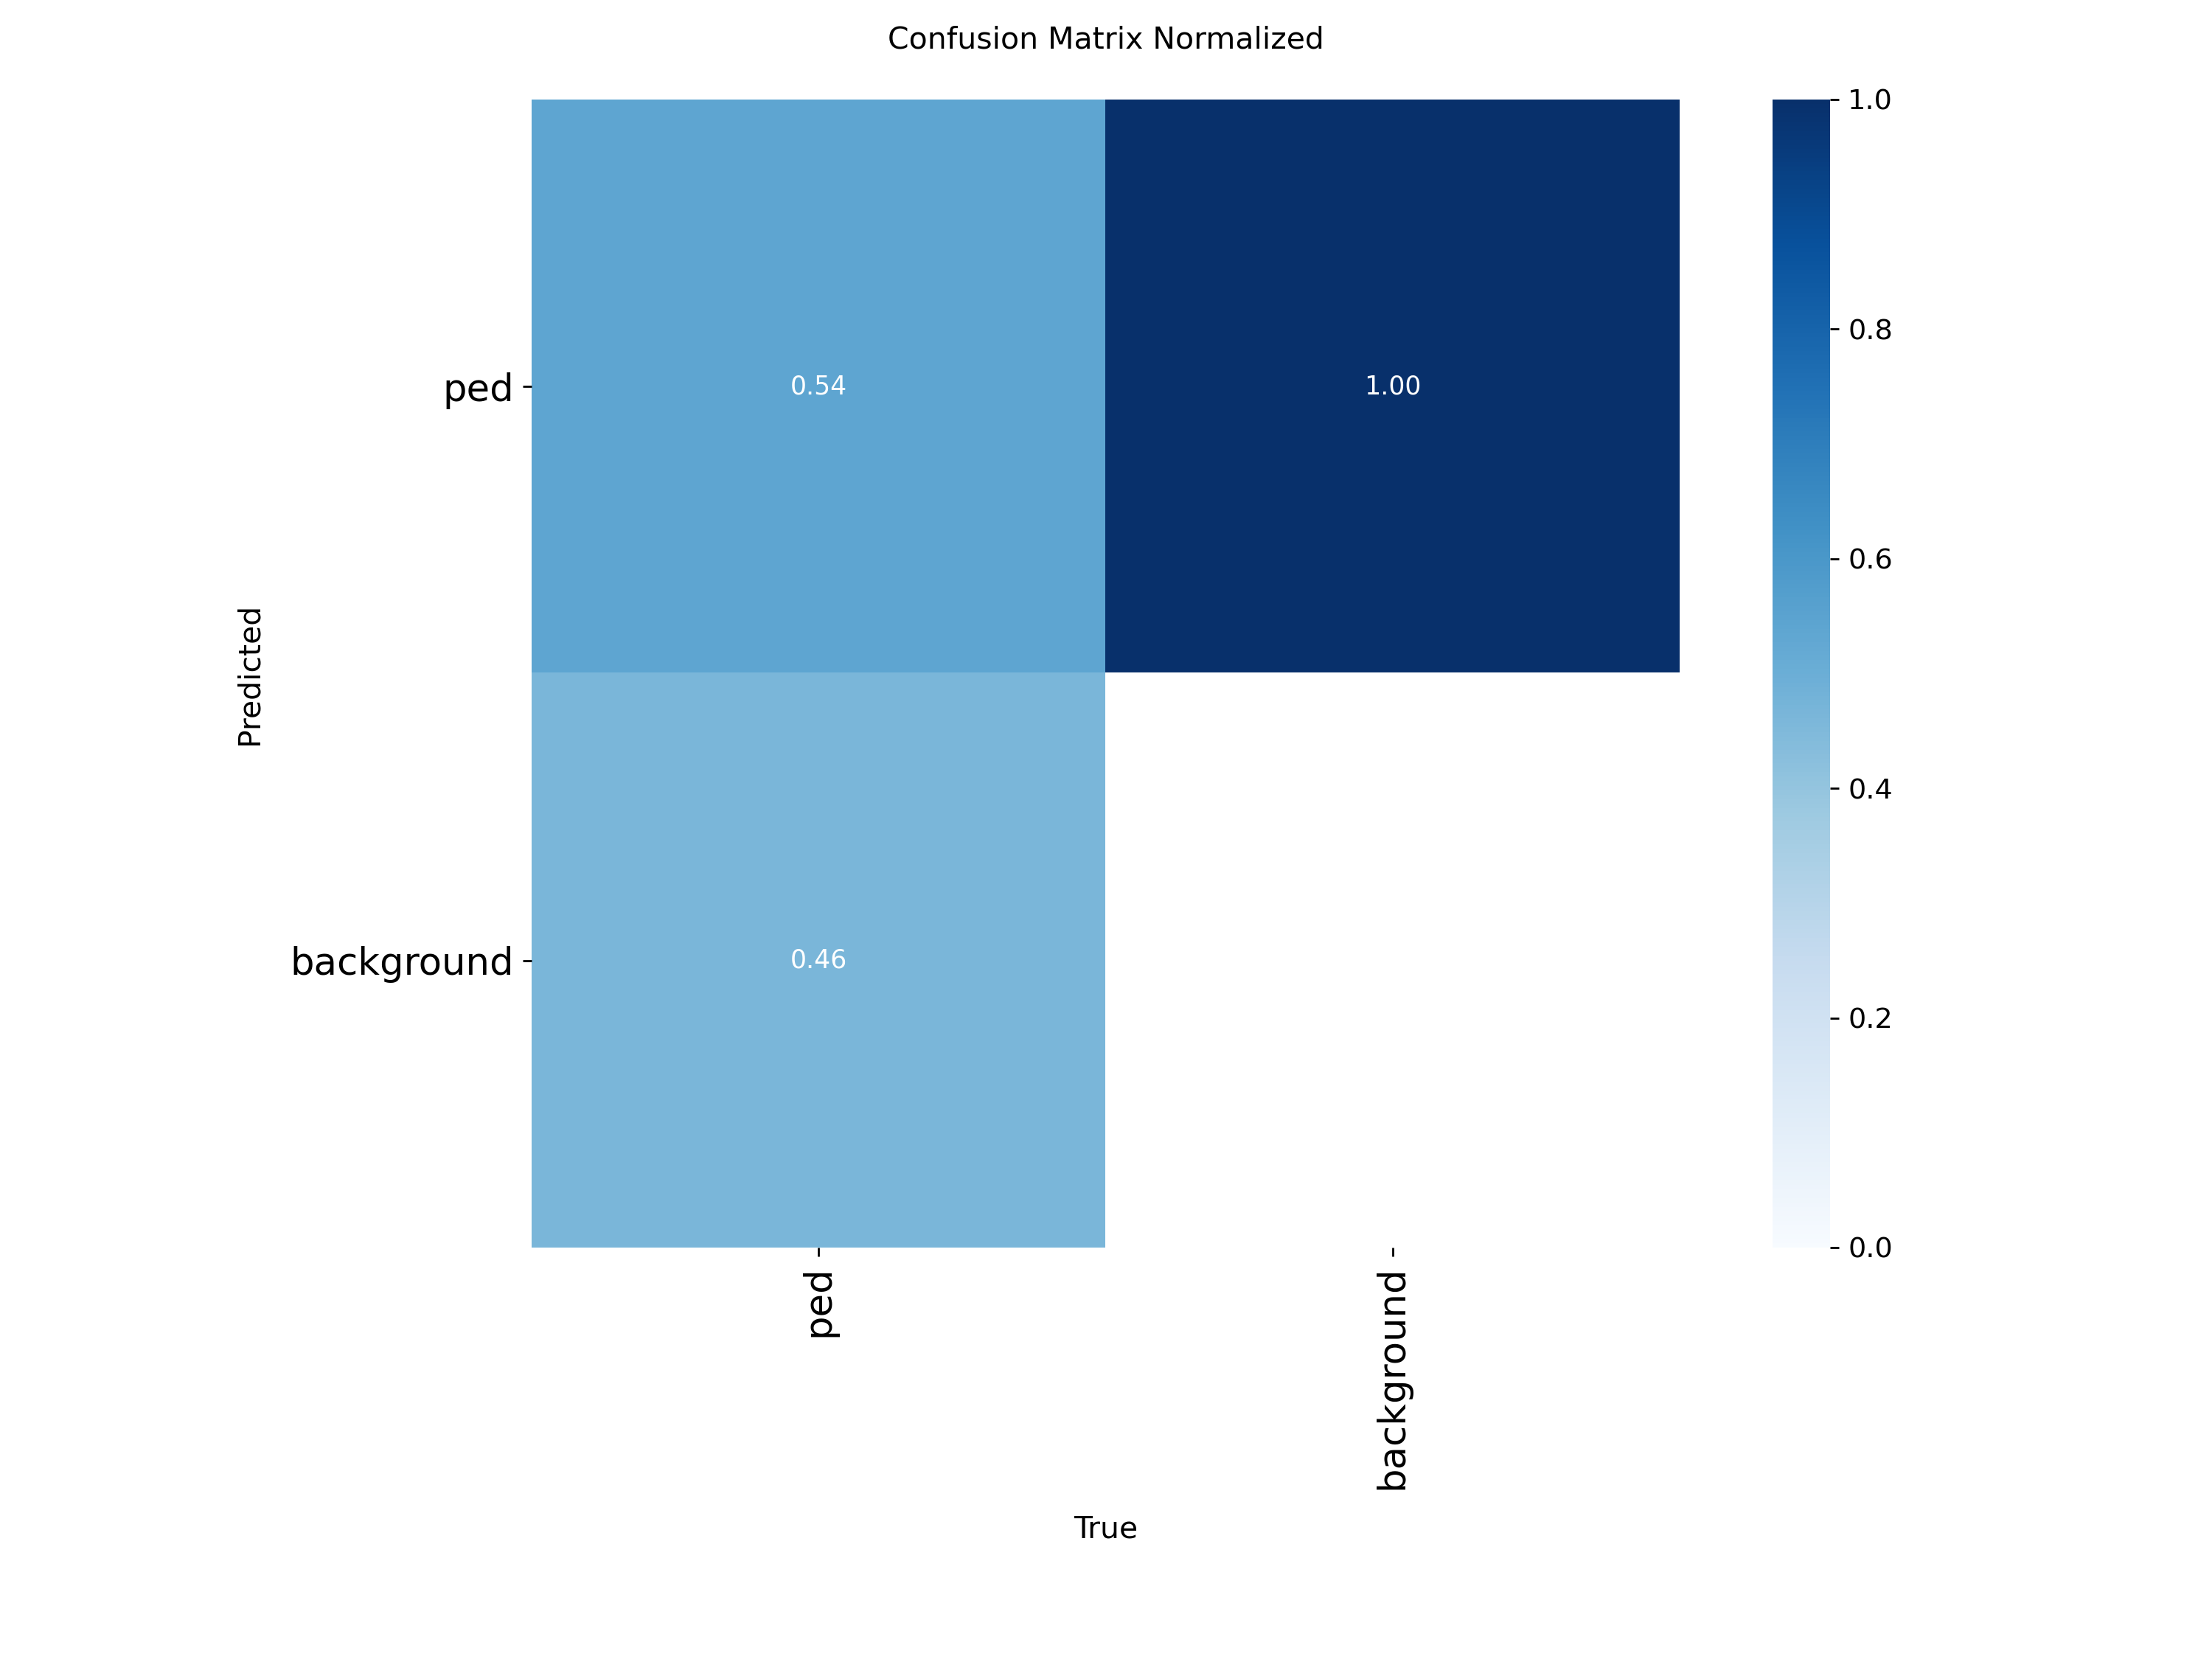

Showing: confusion_matrix.png


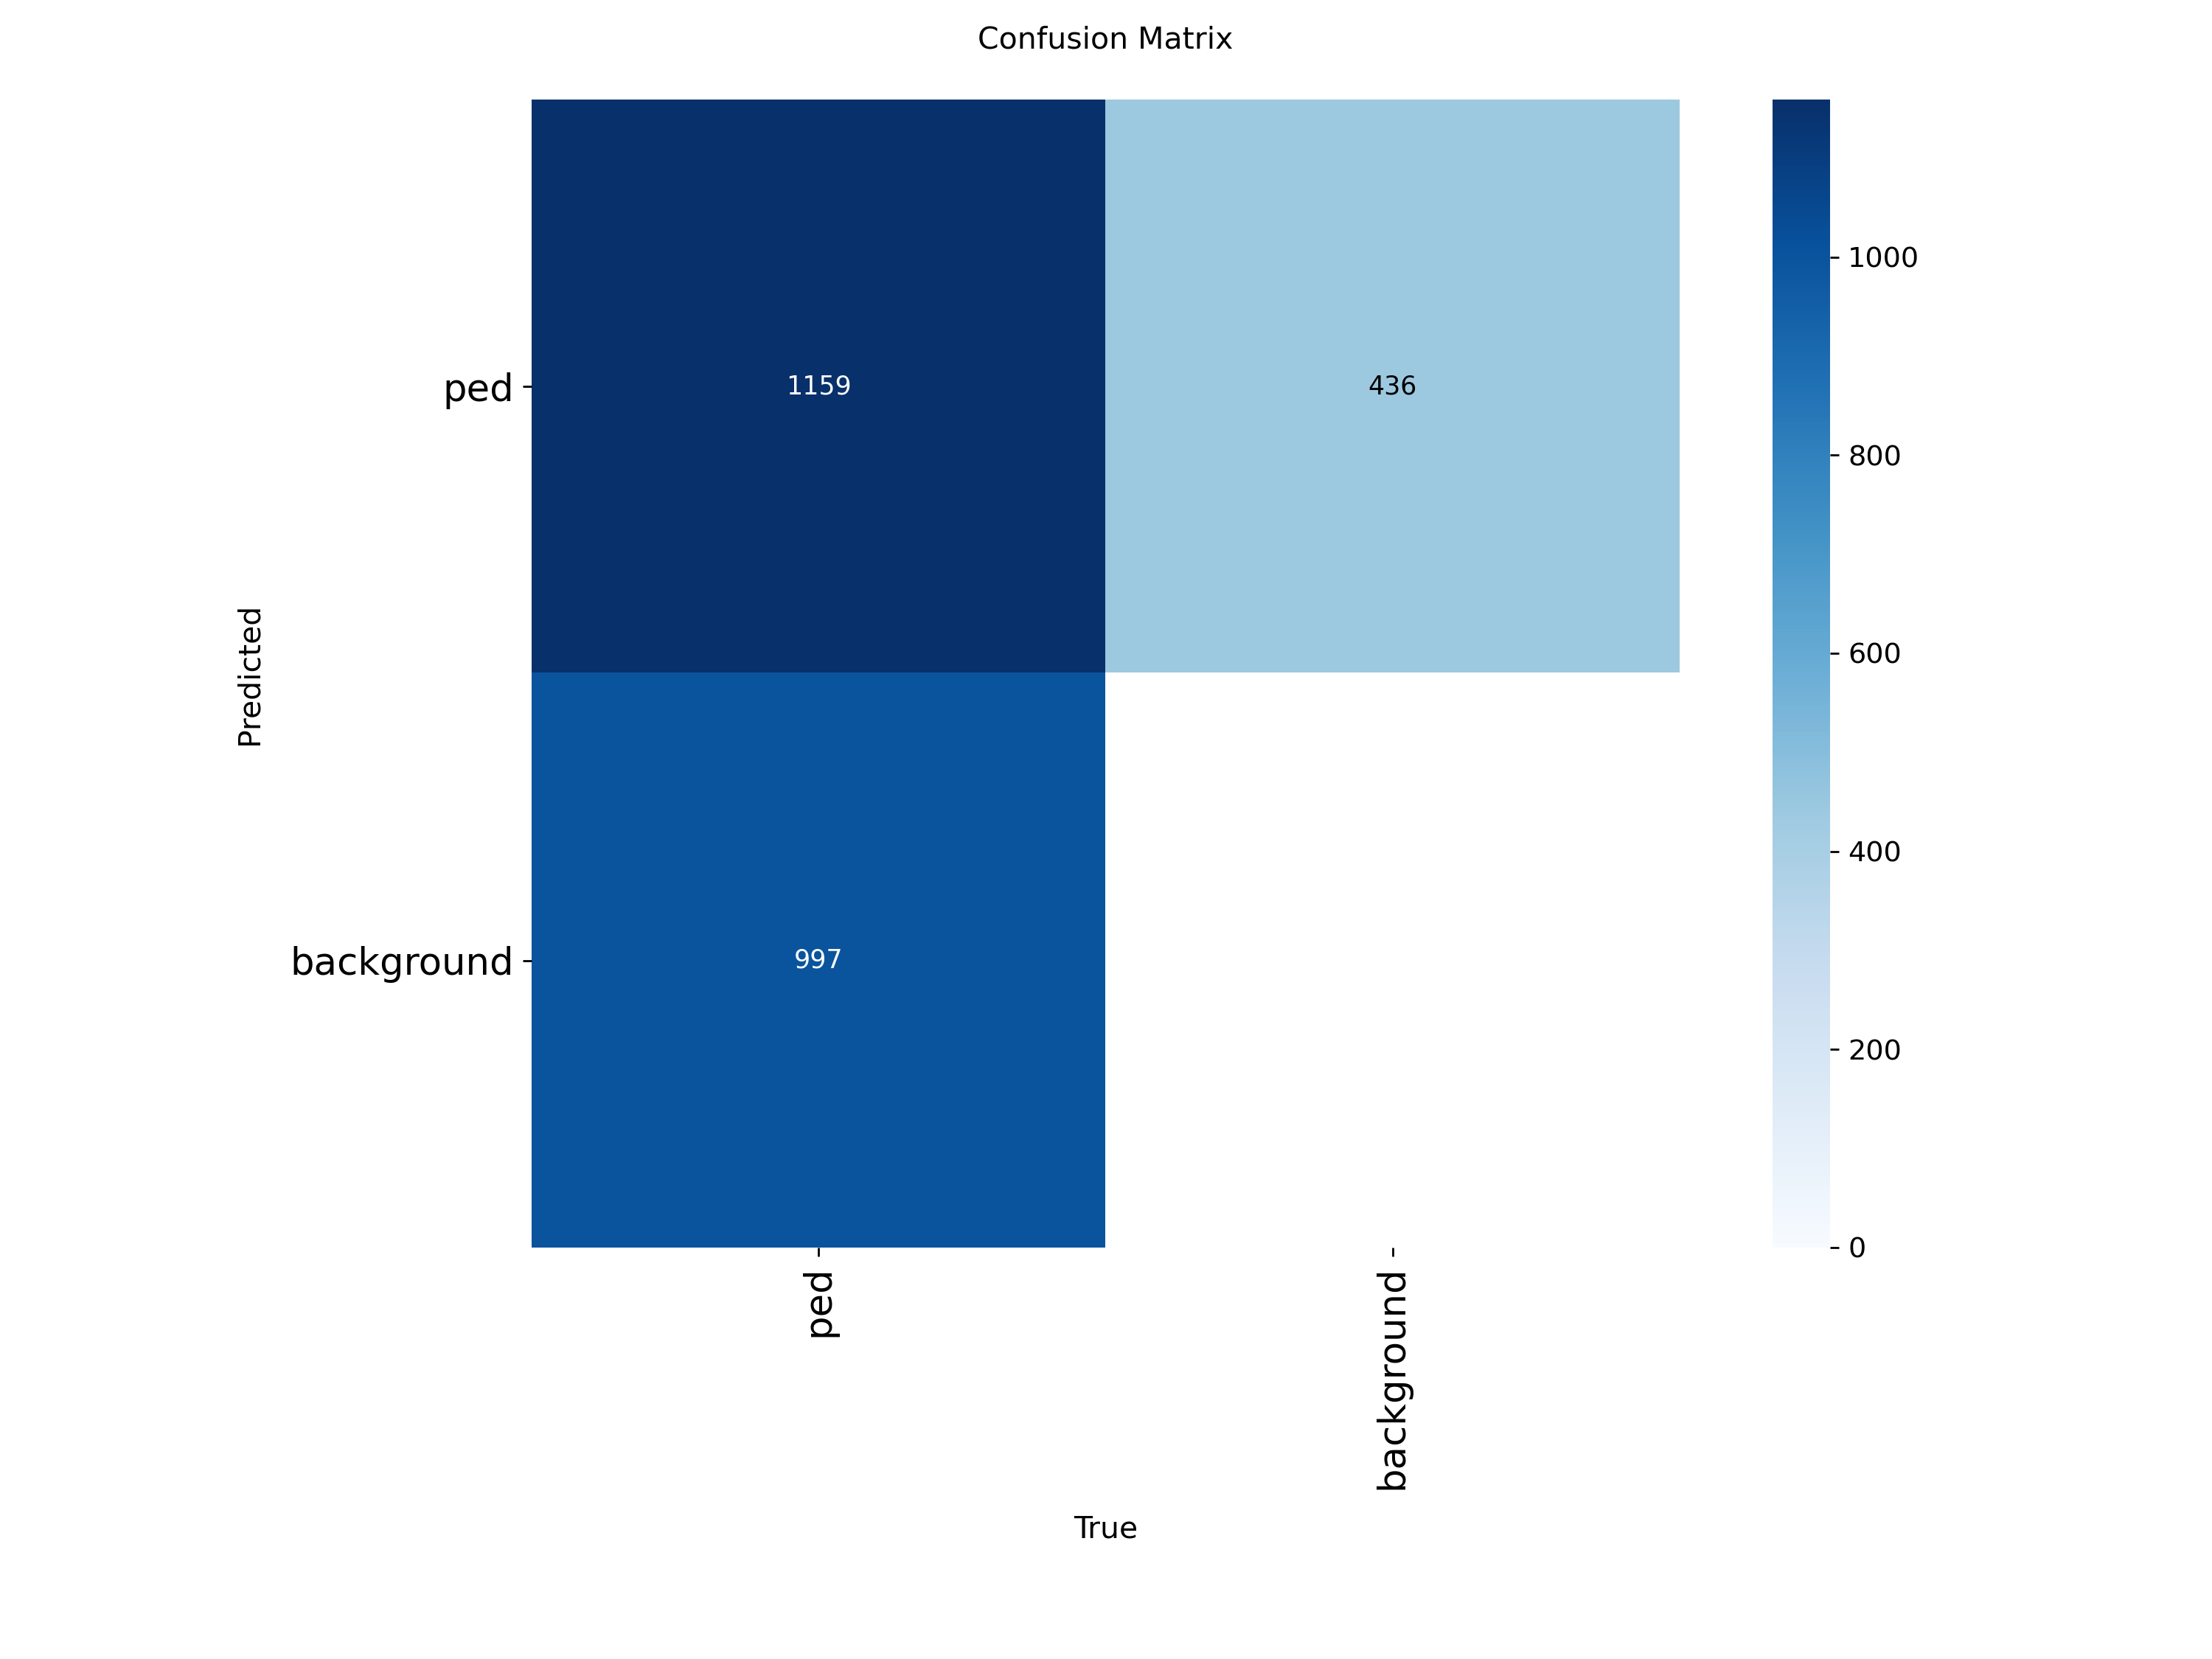

Showing: results.png


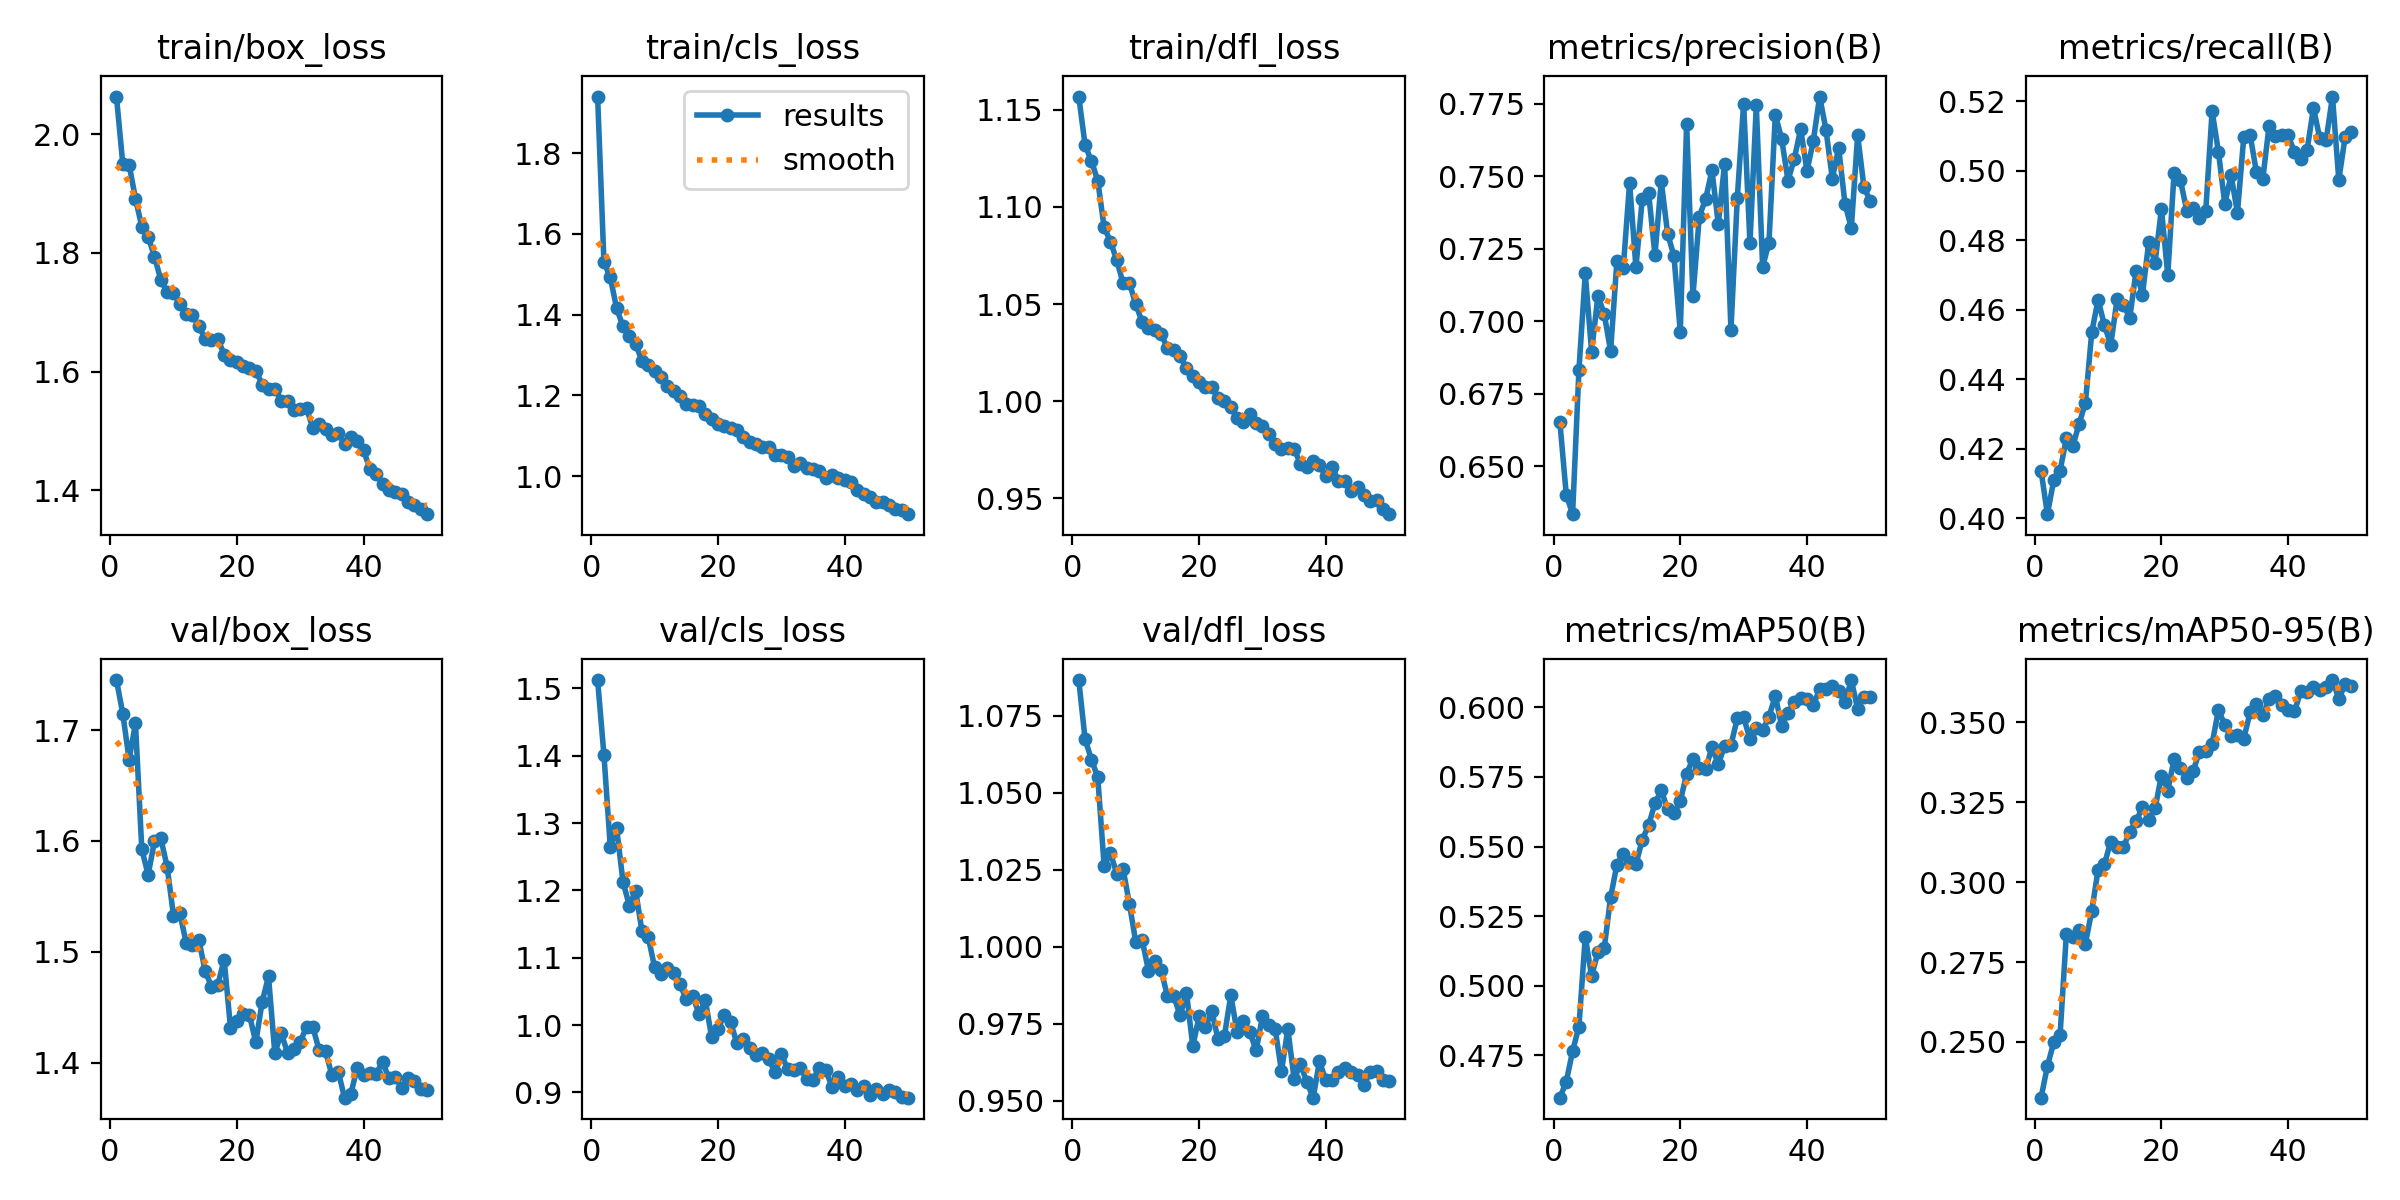

In [9]:
from IPython.display import Image, display
import os

for file in os.listdir(RUN_DIR):
    if file.endswith(".png"):
        print("Showing:", file)
        display(Image(filename=os.path.join(RUN_DIR, file)))

In [5]:
!ls /content/runs/detect/

ls: cannot access '/content/runs/detect/': No such file or directory


In [7]:
!ls "/content/drive/MyDrive/final-year-research/outputs/baseline_train2"

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch13960.jpg  val_batch1_pred.jpg
BoxR_curve.png			 train_batch13961.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch13962.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch1.jpg      weights
labels.jpg			 train_batch2.jpg


In [10]:
import pandas as pd

csv_path = os.path.join(RUN_DIR, "results.csv")
df = pd.read_csv(csv_path)

df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,122.267,2.06309,1.94039,1.15681,0.66504,0.41373,0.45985,0.23258,1.74522,1.51249,1.08667,0.000665,0.000665,0.000665
1,2,240.070,1.94922,1.52983,1.13181,0.64018,0.40121,0.46556,0.24241,1.71479,1.40104,1.06744,0.001305,0.001305,0.001305
2,3,358.489,1.94818,1.49275,1.12360,0.63340,0.41095,0.47654,0.24990,1.67340,1.26456,1.06083,0.001919,0.001919,0.001919
3,4,475.701,1.89120,1.41575,1.11355,0.68302,0.41373,0.48537,0.25221,1.70625,1.29246,1.05510,0.001881,0.001881,0.001881
4,5,592.840,1.84415,1.37113,1.08958,0.71646,0.42301,0.51755,0.28394,1.59243,1.21314,1.02640,0.001842,0.001842,0.001842


In [11]:
df.columns = [c.strip() for c in df.columns]
print(df.columns)

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


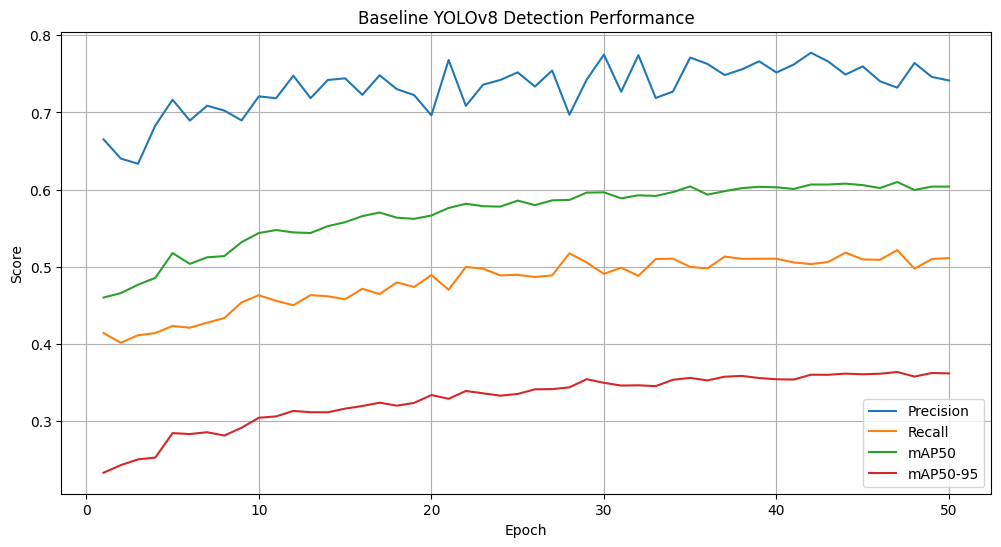

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Baseline YOLOv8 Detection Performance")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
best_row = df.loc[df["metrics/mAP50(B)"].idxmax()]

import pandas as pd

summary = pd.DataFrame([{
    "Experiment": "Baseline",
    "Dataset": "Original CityPersons",
    "Model": "YOLOv8n",
    "Epochs": 50,
    "Best Epoch": int(best_row["epoch"]),
    "Precision": round(best_row["metrics/precision(B)"],3),
    "Recall": round(best_row["metrics/recall(B)"],3),
    "mAP50": round(best_row["metrics/mAP50(B)"],3),
    "mAP50-95": round(best_row["metrics/mAP50-95(B)"],3),
    "Hardware": "Tesla T4 GPU"
}])

summary

,Experiment,Dataset,Model,Epochs,Best Epoch,Precision,Recall,mAP50,mAP50-95,Hardware
0,Baseline,Original CityPersons,YOLOv8n,50,47,0.732,0.521,0.61,0.363,Tesla T4 GPU


In [14]:
summary.to_csv("/content/drive/MyDrive/final-year-research/outputs/baseline_report.csv", index=False)
print("Baseline report saved to Drive")

Baseline report saved to Drive
